In [26]:
import os
from pathlib import Path
import json
import pickle
import numpy as np
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

ModuleNotFoundError: No module named 'tqdm'

In [ ]:
from pathlib import Path

DATA_DIR = Path("/home/toploc1/Datasets/conversational/CAST2019/msmarco/msmarco_embeddings")

for subdir in ["dev_query", "train_query", "train_context"]:
    print(f"\n--- {subdir} ---")
    p = DATA_DIR / subdir
    for f in sorted(p.iterdir()):
        print(f.name)

In [5]:
sample_dev = pd.read_parquet(DATA_DIR /'dev_query' /"embeddings.rank0.part00000.parquet")
sample_dev.head()

,id,embedding
0,174249,"[0.013793945, -0.07324219, -0.0134887695, -0.0..."
1,320792,"[0.018432617, 0.03125, 0.0054626465, 0.0109252..."
2,1090270,"[0.029663086, -0.02734375, 0.030517578, -0.032..."
3,1101279,"[-0.06298828, 0.020507812, -0.052734375, -0.01..."
4,201376,"[0.030151367, 0.038330078, 0.05859375, -0.0397..."


In [6]:
print(sample_dev.columns)
print(sample_dev.dtypes)

Index(['id', 'embedding'], dtype='object')
id           object
embedding    object
dtype: object


In [7]:
json_path = next((DATA_DIR / "dev_query" / "checkpoints").glob("*.json"))
with open(json_path, "r") as f:
    meta = json.load(f)

meta

{'last_byte_offset': 81013, 'out_parts': 1}

In [8]:
def count_rows(parquet_dir):
    total = 0
    for f in parquet_dir.glob("*.parquet"):
        df = pd.read_parquet(f)
        total += len(df)
    return total

for subdir in ["dev_query", "train_query", "train_context"]:
    total = count_rows(DATA_DIR / subdir)
    print(subdir, total)

dev_query 5193
train_query 367013
train_context 367013


In [11]:
def inspect_embedding_dim(parquet_file, emb_col):
    df = pd.read_parquet(parquet_file)
    vec = df.iloc[0][emb_col]
    print(type(vec), len(vec))

inspect_embedding_dim(DATA_DIR / "dev_query" / "/home/toploc1/Datasets/conversational/CAST2019/msmarco/msmarco_embeddings/train_query/embeddings.rank0.part00000.parquet", "embedding")

<class 'numpy.ndarray'> 1024


aaa

In [14]:
DATA_ROOT = Path("/home/toploc1/Datasets/conversational/CAST2019/msmarco/msmarco_embeddings")

TRAIN_CONTEXT_DIR = DATA_ROOT / "train_context"
TRAIN_QUERY_DIR = DATA_ROOT / "train_query"
DEV_QUERY_DIR = DATA_ROOT / "dev_query"

assert TRAIN_CONTEXT_DIR.exists(), TRAIN_CONTEXT_DIR
assert TRAIN_QUERY_DIR.exists(), TRAIN_QUERY_DIR
assert DEV_QUERY_DIR.exists(), DEV_QUERY_DIR

print("DATA_ROOT:", DATA_ROOT)

DATA_ROOT: /home/toploc1/Datasets/conversational/CAST2019/msmarco/msmarco_embeddings


In [15]:
def list_files(folder: Path):
    return sorted([p for p in folder.iterdir() if p.is_file()])

def list_recursive(folder: Path):
    return sorted([p for p in folder.rglob("*") if p.is_file()])

def parquet_files(folder: Path):
    return sorted(folder.glob("*.parquet"))

def checkpoint_jsons(folder: Path):
    ckpt_dir = folder / "checkpoints"
    if not ckpt_dir.exists():
        return []
    return sorted(ckpt_dir.glob("*.json"))

def pretty_size(num_bytes: int):
    for unit in ["B", "KB", "MB", "GB", "TB"]:
        if num_bytes < 1024:
            return f"{num_bytes:.2f} {unit}"
        num_bytes /= 1024
    return f"{num_bytes:.2f} PB"

In [16]:
for name, folder in [
    ("train_context", TRAIN_CONTEXT_DIR),
    ("train_query", TRAIN_QUERY_DIR),
    ("dev_query", DEV_QUERY_DIR),
]:
    print(f"\n=== {name} ===")
    files = list_recursive(folder)
    for f in files[:20]:
        print(f.relative_to(DATA_ROOT), "|", pretty_size(f.stat().st_size))
    if len(files) > 20:
        print(f"... and {len(files) - 20} more files")


=== train_context ===
train_context/checkpoints/rank_0_state.json | 45.00 B
train_context/checkpoints/rank_1_state.json | 45.00 B
train_context/checkpoints/rank_2_state.json | 45.00 B
train_context/checkpoints/rank_3_state.json | 46.00 B
train_context/checkpoints/rank_4_state.json | 46.00 B
train_context/checkpoints/rank_5_state.json | 46.00 B
train_context/checkpoints/rank_6_state.json | 46.00 B
train_context/checkpoints/rank_7_state.json | 46.00 B
train_context/embeddings.rank0.part00000.parquet | 72.30 MB
train_context/embeddings.rank1.part00000.parquet | 71.77 MB
train_context/embeddings.rank2.part00000.parquet | 69.38 MB
train_context/embeddings.rank3.part00000.parquet | 68.84 MB
train_context/embeddings.rank4.part00000.parquet | 69.07 MB
train_context/embeddings.rank5.part00000.parquet | 69.47 MB
train_context/embeddings.rank6.part00000.parquet | 69.94 MB
train_context/embeddings.rank7.part00000.parquet | 70.97 MB

=== train_query ===
train_query/checkpoints/rank_0_state.json | 

In [17]:
summary = []

for name, folder in [
    ("train_context", TRAIN_CONTEXT_DIR),
    ("train_query", TRAIN_QUERY_DIR),
    ("dev_query", DEV_QUERY_DIR),
]:
    pq = parquet_files(folder)
    ck = checkpoint_jsons(folder)
    summary.append({
        "split": name,
        "num_parquet": len(pq),
        "num_checkpoint_json": len(ck),
        "parquet_total_size": sum(p.stat().st_size for p in pq),
    })

summary_df = pd.DataFrame(summary)
summary_df["parquet_total_size_human"] = summary_df["parquet_total_size"].map(pretty_size)
summary_df

,split,num_parquet,num_checkpoint_json,parquet_total_size,parquet_total_size_human
0,train_context,8,8,589026770,561.74 MB
1,train_query,8,8,588862389,561.58 MB
2,dev_query,8,8,7841372,7.48 MB


In [18]:
def inspect_checkpoint_jsons(folder: Path, max_files=3):
    files = checkpoint_jsons(folder)[:max_files]
    out = []
    for f in files:
        with open(f, "r") as fh:
            data = json.load(fh)
        out.append((f.name, data))
    return out

for name, folder in [
    ("train_context", TRAIN_CONTEXT_DIR),
    ("train_query", TRAIN_QUERY_DIR),
    ("dev_query", DEV_QUERY_DIR),
]:
    print(f"\n=== checkpoint jsons: {name} ===")
    infos = inspect_checkpoint_jsons(folder)
    if not infos:
        print("No checkpoint JSONs found")
        continue
    for fname, data in infos:
        print(f"\n--- {fname} ---")
        if isinstance(data, dict):
            print("keys:", list(data.keys())[:30])
            print(json.dumps(data, indent=2)[:2000])
        else:
            print(type(data), str(data)[:1000])


=== checkpoint jsons: train_context ===

--- rank_0_state.json ---
keys: ['last_byte_offset', 'out_parts']
{
  "last_byte_offset": 2852575,
  "out_parts": 1
}

--- rank_1_state.json ---
keys: ['last_byte_offset', 'out_parts']
{
  "last_byte_offset": 5705287,
  "out_parts": 1
}

--- rank_2_state.json ---
keys: ['last_byte_offset', 'out_parts']
{
  "last_byte_offset": 8557924,
  "out_parts": 1
}

=== checkpoint jsons: train_query ===

--- rank_0_state.json ---
keys: ['last_byte_offset', 'out_parts']
{
  "last_byte_offset": 2852575,
  "out_parts": 1
}

--- rank_1_state.json ---
keys: ['last_byte_offset', 'out_parts']
{
  "last_byte_offset": 5705287,
  "out_parts": 1
}

--- rank_2_state.json ---
keys: ['last_byte_offset', 'out_parts']
{
  "last_byte_offset": 8557924,
  "out_parts": 1
}

=== checkpoint jsons: dev_query ===

--- rank_0_state.json ---
keys: ['last_byte_offset', 'out_parts']
{
  "last_byte_offset": 40477,
  "out_parts": 1
}

--- rank_1_state.json ---
keys: ['last_byte_offset'

In [19]:
def inspect_one_parquet(folder: Path):
    pq_files = parquet_files(folder)
    assert len(pq_files) > 0, f"No parquet files in {folder}"
    sample_file = pq_files[0]
    df = pd.read_parquet(sample_file)
    print("file:", sample_file.name)
    print("shape:", df.shape)
    print("columns:", list(df.columns))
    print("\ndtypes:")
    print(df.dtypes)
    return df

train_context_sample = inspect_one_parquet(TRAIN_CONTEXT_DIR)
train_query_sample = inspect_one_parquet(TRAIN_QUERY_DIR)
dev_query_sample = inspect_one_parquet(DEV_QUERY_DIR)

file: embeddings.rank0.part00000.parquet
shape: (47216, 2)
columns: ['id', 'embedding']

dtypes:
id           object
embedding    object
dtype: object
file: embeddings.rank0.part00000.parquet
shape: (47216, 2)
columns: ['id', 'embedding']

dtypes:
id           object
embedding    object
dtype: object
file: embeddings.rank0.part00000.parquet
shape: (658, 2)
columns: ['id', 'embedding']

dtypes:
id           object
embedding    object
dtype: object


In [20]:
display(train_context_sample.head(3))
display(train_query_sample.head(3))
display(dev_query_sample.head(3))

,id,embedding
0,1185869,"[0.03173828, 0.042236328, 0.022094727, -0.0136..."
1,1185868,"[-0.01184082, -0.0029296875, 0.007232666, -0.0..."
2,1183785,"[0.036621094, -0.008422852, 0.018676758, -0.00..."


,id,embedding
0,1185869,"[0.04638672, 0.04736328, 0.013366699, 0.020629..."
1,1185868,"[0.0022735596, 0.018554688, -0.0053710938, -0...."
2,1183785,"[0.016723633, 0.022949219, 0.019897461, 0.0277..."


,id,embedding
0,174249,"[0.013793945, -0.07324219, -0.0134887695, -0.0..."
1,320792,"[0.018432617, 0.03125, 0.0054626465, 0.0109252..."
2,1090270,"[0.029663086, -0.02734375, 0.030517578, -0.032..."


In [21]:
def parquet_row_counts(folder: Path):
    rows = []
    for f in parquet_files(folder):
        df = pd.read_parquet(f, columns=None)
        rows.append({"file": f.name, "rows": len(df)})
    return pd.DataFrame(rows)

train_context_rows = parquet_row_counts(TRAIN_CONTEXT_DIR)
train_query_rows = parquet_row_counts(TRAIN_QUERY_DIR)
dev_query_rows = parquet_row_counts(DEV_QUERY_DIR)

display(train_context_rows.head())
display(train_query_rows.head())
display(dev_query_rows.head())

,file,rows
0,embeddings.rank0.part00000.parquet,47216
1,embeddings.rank1.part00000.parquet,46884
2,embeddings.rank2.part00000.parquet,45340
3,embeddings.rank3.part00000.parquet,44997
4,embeddings.rank4.part00000.parquet,45092


,file,rows
0,embeddings.rank0.part00000.parquet,47216
1,embeddings.rank1.part00000.parquet,46884
2,embeddings.rank2.part00000.parquet,45340
3,embeddings.rank3.part00000.parquet,44997
4,embeddings.rank4.part00000.parquet,45092


,file,rows
0,embeddings.rank0.part00000.parquet,658
1,embeddings.rank1.part00000.parquet,633
2,embeddings.rank2.part00000.parquet,632
3,embeddings.rank3.part00000.parquet,653
4,embeddings.rank4.part00000.parquet,661


In [24]:
TRAIN_CONTEXT_ID_COL = "id"          
TRAIN_CONTEXT_EMB_COL = "embedding"  

TRAIN_QUERY_ID_COL = "id"            
TRAIN_QUERY_EMB_COL = "embedding"

DEV_QUERY_ID_COL = "id"
DEV_QUERY_EMB_COL = "embedding"

In [29]:
def inspect_embedding_value(df: pd.DataFrame, emb_col: str):
    vec = df.iloc[0][emb_col]
    print("type:", type(vec))
    print("length:", len(vec))
    print("first 10 values:", list(vec[:10]))

inspect_embedding_value(train_context_sample, TRAIN_CONTEXT_EMB_COL)
inspect_embedding_value(train_query_sample, TRAIN_QUERY_EMB_COL)
inspect_embedding_value(dev_query_sample, DEV_QUERY_EMB_COL)

type: <class 'numpy.ndarray'>
length: 1024
first 10 values: [0.03173828, 0.042236328, 0.022094727, -0.01361084, -0.010131836, 0.038330078, -0.0026397705, 0.07470703, 0.0134887695, -0.0046081543]
type: <class 'numpy.ndarray'>
length: 1024
first 10 values: [0.04638672, 0.04736328, 0.013366699, 0.020629883, 0.004119873, 0.059326172, 0.011291504, 0.04711914, 0.018798828, -0.017089844]
type: <class 'numpy.ndarray'>
length: 1024
first 10 values: [0.013793945, -0.07324219, -0.0134887695, -0.0009384155, 0.012207031, 0.03466797, 0.061523438, -0.018798828, 0.11279297, -0.10107422]


In [30]:
def parquet_row_counts(folder: Path):
    rows = []
    for f in parquet_files(folder):
        df = pd.read_parquet(f, columns=None)
        rows.append({"file": f.name, "rows": len(df)})
    return pd.DataFrame(rows)

train_context_rows = parquet_row_counts(TRAIN_CONTEXT_DIR)
train_query_rows = parquet_row_counts(TRAIN_QUERY_DIR)
dev_query_rows = parquet_row_counts(DEV_QUERY_DIR)

display(train_context_rows.head())
display(train_query_rows.head())
display(dev_query_rows.head())

,file,rows
0,embeddings.rank0.part00000.parquet,47216
1,embeddings.rank1.part00000.parquet,46884
2,embeddings.rank2.part00000.parquet,45340
3,embeddings.rank3.part00000.parquet,44997
4,embeddings.rank4.part00000.parquet,45092


,file,rows
0,embeddings.rank0.part00000.parquet,47216
1,embeddings.rank1.part00000.parquet,46884
2,embeddings.rank2.part00000.parquet,45340
3,embeddings.rank3.part00000.parquet,44997
4,embeddings.rank4.part00000.parquet,45092


,file,rows
0,embeddings.rank0.part00000.parquet,658
1,embeddings.rank1.part00000.parquet,633
2,embeddings.rank2.part00000.parquet,632
3,embeddings.rank3.part00000.parquet,653
4,embeddings.rank4.part00000.parquet,661


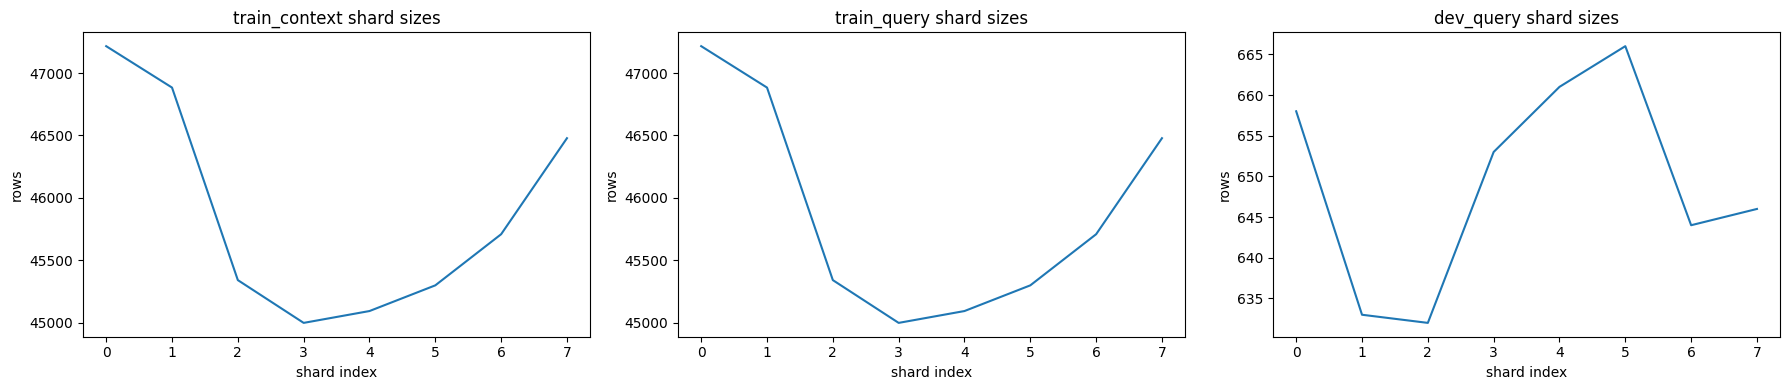

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, df, title in [
    (axes[0], train_context_rows, "train_context shard sizes"),
    (axes[1], train_query_rows, "train_query shard sizes"),
    (axes[2], dev_query_rows, "dev_query shard sizes"),
]:
    ax.plot(df["rows"].values)
    ax.set_title(title)
    ax.set_xlabel("shard index")
    ax.set_ylabel("rows")

plt.tight_layout()
plt.show()

In [28]:
def load_ids_from_parquets(folder: Path, id_col: str):
    ids = []
    for f in parquet_files(folder):        
        df = pd.read_parquet(f, columns=[id_col])
        ids.extend(df[id_col].tolist())
    return ids

train_context_ids = load_ids_from_parquets(TRAIN_CONTEXT_DIR, TRAIN_CONTEXT_ID_COL)
train_query_ids = load_ids_from_parquets(TRAIN_QUERY_DIR, TRAIN_QUERY_ID_COL)
dev_query_ids = load_ids_from_parquets(DEV_QUERY_DIR, DEV_QUERY_ID_COL)

print("Loaded ids.")

Loaded ids.


In [32]:
def id_stats(ids, name):
    s = pd.Series(ids)
    print(f"\n{name}")
    print("count:", len(s))
    print("unique:", s.nunique())
    print("duplicates:", len(s) - s.nunique())

id_stats(train_context_ids, "train_context ids")
id_stats(train_query_ids, "train_query ids")
id_stats(dev_query_ids, "dev_query ids")


train_context ids
count: 367013
unique: 367013
duplicates: 0

train_query ids
count: 367013
unique: 367013
duplicates: 0

dev_query ids
count: 5193
unique: 5193
duplicates: 0


In [33]:
train_query_id_set = set(train_query_ids)
dev_query_id_set = set(dev_query_ids)

print("train/dev query id overlap:", len(train_query_id_set & dev_query_id_set))

train/dev query id overlap: 0


In [34]:
def sample_embeddings(folder: Path, emb_col: str, n_files=2, n_rows_per_file=2000):
    vecs = []
    files = parquet_files(folder)[:n_files]
    for f in files:
        df = pd.read_parquet(f, columns=[emb_col])
        sample = df[emb_col].iloc[:n_rows_per_file].tolist()
        vecs.extend(sample)
    arr = np.array(vecs, dtype=np.float32)
    return arr

train_context_emb_sample = sample_embeddings(TRAIN_CONTEXT_DIR, TRAIN_CONTEXT_EMB_COL)
train_query_emb_sample = sample_embeddings(TRAIN_QUERY_DIR, TRAIN_QUERY_EMB_COL)
dev_query_emb_sample = sample_embeddings(DEV_QUERY_DIR, DEV_QUERY_EMB_COL)

print(train_context_emb_sample.shape)
print(train_query_emb_sample.shape)
print(dev_query_emb_sample.shape)

(4000, 1024)
(4000, 1024)
(1291, 1024)


In [35]:
print("train_context dim:", train_context_emb_sample.shape[1])
print("train_query dim:", train_query_emb_sample.shape[1])
print("dev_query dim:", dev_query_emb_sample.shape[1])

train_context dim: 1024
train_query dim: 1024
dev_query dim: 1024


In [36]:
def norm_stats(arr, name):
    norms = np.linalg.norm(arr, axis=1)
    print(f"\n{name}")
    print("min:", norms.min())
    print("max:", norms.max())
    print("mean:", norms.mean())
    print("std:", norms.std())
    return norms

train_context_norms = norm_stats(train_context_emb_sample, "train_context")
train_query_norms = norm_stats(train_query_emb_sample, "train_query")
dev_query_norms = norm_stats(dev_query_emb_sample, "dev_query")


train_context
min: 0.9972931
max: 1.0027831
mean: 1.0000386
std: 0.0014345367

train_query
min: 0.9973395
max: 1.0026345
mean: 1.0000415
std: 0.0013956798

dev_query
min: 0.99737144
max: 1.0027398
mean: 1.0000643
std: 0.0013984794


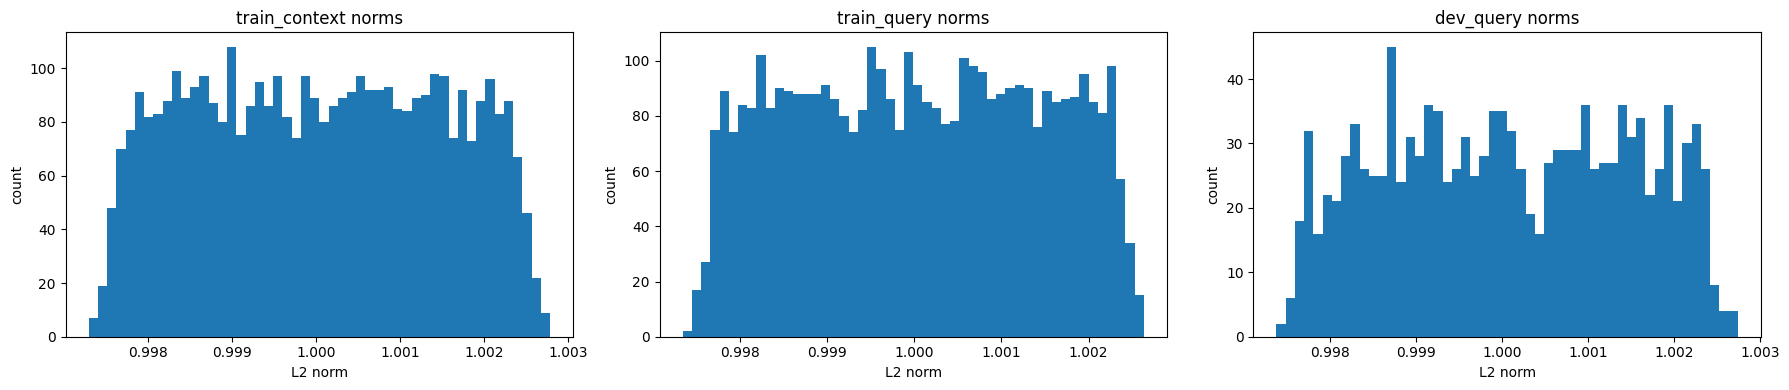

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, norms, title in [
    (axes[0], train_context_norms, "train_context norms"),
    (axes[1], train_query_norms, "train_query norms"),
    (axes[2], dev_query_norms, "dev_query norms"),
]:
    ax.hist(norms, bins=50)
    ax.set_title(title)
    ax.set_xlabel("L2 norm")
    ax.set_ylabel("count")

plt.tight_layout()
plt.show()

In [39]:
QUERIES_DIR = Path("/home/toploc1/Datasets/conversational/CAST2019/msmarco/msmarco_queries")
TRAIN_QUERIES_JSONL = QUERIES_DIR / "train_queries.jsonl"
DEV_QUERIES_JSONL = QUERIES_DIR / "dev_queries.jsonl"

def peek_jsonl(path, n=3):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for i, line in enumerate(f):
            rows.append(json.loads(line))
            if i + 1 >= n:
                break
    return rows

print("TRAIN sample:")
for row in peek_jsonl(TRAIN_QUERIES_JSONL):
    print(row)

print("\nDEV sample:")
for row in peek_jsonl(DEV_QUERIES_JSONL):
    print(row)

TRAIN sample:
{'id': '1185869', 'text': ')what was the immediate impact of the success of the manhattan project?'}
{'id': '1185868', 'text': '_________ justice is designed to repair the harm to victim, the community and the offender caused by the offender criminal act. question 19 options:'}
{'id': '1183785', 'text': 'elegxo meaning'}

DEV sample:
{'id': '174249', 'text': 'does xpress bet charge to deposit money in your account'}
{'id': '320792', 'text': 'how much is a cost to run disneyland'}
{'id': '1090270', 'text': 'botulinum definition'}


In [40]:
def load_jsonl(path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            rows.append(json.loads(line))
    return pd.DataFrame(rows)

train_queries_text_df = load_jsonl(TRAIN_QUERIES_JSONL)
dev_queries_text_df = load_jsonl(DEV_QUERIES_JSONL)

display(train_queries_text_df.head())
display(dev_queries_text_df.head())
print(train_queries_text_df.columns)
print(dev_queries_text_df.columns)

,id,text
0,1185869,)what was the immediate impact of the success ...
1,1185868,_________ justice is designed to repair the ha...
2,1183785,elegxo meaning
3,645590,what does physical medicine do
4,186154,feeding rice cereal how many times per day


,id,text
0,174249,does xpress bet charge to deposit money in you...
1,320792,how much is a cost to run disneyland
2,1090270,botulinum definition
3,1101279,do physicians pay for insurance from their sal...
4,201376,here there be dragons comic


Index(['id', 'text'], dtype='object')
Index(['id', 'text'], dtype='object')


In [41]:
# example: build query id dataframe from parquet ids
train_query_ids_df = pd.DataFrame({"id": train_query_ids})
dev_query_ids_df = pd.DataFrame({"id": dev_query_ids})

train_query_merged = train_query_ids_df.merge(train_queries_text_df, on="id", how="left")
dev_query_merged = dev_query_ids_df.merge(dev_queries_text_df, on="id", how="left")

display(train_query_merged.head())
display(dev_query_merged.head())

print("Missing train texts:", train_query_merged["text"].isna().sum())
print("Missing dev texts:", dev_query_merged["text"].isna().sum())

,id,text
0,1185869,)what was the immediate impact of the success ...
1,1185868,_________ justice is designed to repair the ha...
2,1183785,elegxo meaning
3,645590,what does physical medicine do
4,186154,feeding rice cereal how many times per day


,id,text
0,174249,does xpress bet charge to deposit money in you...
1,320792,how much is a cost to run disneyland
2,1090270,botulinum definition
3,1101279,do physicians pay for insurance from their sal...
4,201376,here there be dragons comic


Missing train texts: 0
Missing dev texts: 0


In [42]:
def load_jsonl(path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            rows.append(json.loads(line))
    return pd.DataFrame(rows)

train_queries_text_df = load_jsonl(TRAIN_QUERIES_JSONL)
dev_queries_text_df = load_jsonl(DEV_QUERIES_JSONL)

print("train_queries_text_df shape:", train_queries_text_df.shape)
print("dev_queries_text_df shape:", dev_queries_text_df.shape)

display(train_queries_text_df.head())
display(dev_queries_text_df.head())
print("train columns:", list(train_queries_text_df.columns))
print("dev columns:", list(dev_queries_text_df.columns))

train_queries_text_df shape: (367013, 2)
dev_queries_text_df shape: (5193, 2)


,id,text
0,1185869,)what was the immediate impact of the success ...
1,1185868,_________ justice is designed to repair the ha...
2,1183785,elegxo meaning
3,645590,what does physical medicine do
4,186154,feeding rice cereal how many times per day


,id,text
0,174249,does xpress bet charge to deposit money in you...
1,320792,how much is a cost to run disneyland
2,1090270,botulinum definition
3,1101279,do physicians pay for insurance from their sal...
4,201376,here there be dragons comic


train columns: ['id', 'text']
dev columns: ['id', 'text']


In [44]:
print("Number of train query texts:", len(train_queries_text_df))
print("Number of dev query texts:", len(dev_queries_text_df))

print("Unique train query text IDs:", train_queries_text_df['id'].nunique())
print("Unique dev query text IDs:", dev_queries_text_df['id'].nunique())

Number of train query texts: 367013
Number of dev query texts: 5193
Unique train query text IDs: 367013
Unique dev query text IDs: 5193


In [45]:
print("Number of train query embeddings:", len(train_query_ids))
print("Number of dev query embeddings:", len(dev_query_ids))

print("Unique train query embedding IDs:", len(set(train_query_ids)))
print("Unique dev query embedding IDs:", len(set(dev_query_ids)))

Number of train query embeddings: 367013
Number of dev query embeddings: 5193
Unique train query embedding IDs: 367013
Unique dev query embedding IDs: 5193


In [46]:
print("TRAIN count match:", len(train_queries_text_df) == len(train_query_ids))
print("DEV count match:", len(dev_queries_text_df) == len(dev_query_ids))

TRAIN count match: True
DEV count match: True


In [47]:
train_text_id_set = set(train_queries_text_df['id'].astype(str))
dev_text_id_set = set(dev_queries_text_df['id'].astype(str))

train_emb_id_set = set(map(str, train_query_ids))
dev_emb_id_set = set(map(str, dev_query_ids))

print("Train IDs in both:", len(train_text_id_set & train_emb_id_set))
print("Train IDs only in text:", len(train_text_id_set - train_emb_id_set))
print("Train IDs only in embeddings:", len(train_emb_id_set - train_text_id_set))

print("Dev IDs in both:", len(dev_text_id_set & dev_emb_id_set))
print("Dev IDs only in text:", len(dev_text_id_set - dev_emb_id_set))
print("Dev IDs only in embeddings:", len(dev_emb_id_set - dev_text_id_set))

Train IDs in both: 367013
Train IDs only in text: 0
Train IDs only in embeddings: 0
Dev IDs in both: 5193
Dev IDs only in text: 0
Dev IDs only in embeddings: 0


In [48]:
print(train_context_emb_sample.shape)
print(train_query_emb_sample.shape)
print(dev_query_emb_sample.shape)

for name, arr in [
    ("docs", train_context_emb_sample),
    ("train_q", train_query_emb_sample),
    ("dev_q", dev_query_emb_sample),
]:
    norms = np.linalg.norm(arr, axis=1)
    print(name, norms.min(), norms.mean(), norms.max(), norms.std())

(4000, 1024)
(4000, 1024)
(1291, 1024)
docs 0.9972931 1.0000386 1.0027831 0.0014345367
train_q 0.9973395 1.0000415 1.0026345 0.0013956798
dev_q 0.99737144 1.0000643 1.0027398 0.0013984794


In [49]:
dev_small = dev_query_emb_sample[:100]
train_small = train_query_emb_sample[:5000]

scores = dev_small @ train_small.T
top1 = scores.max(axis=1)

print("top1 similarity stats:")
print(top1.min(), top1.mean(), top1.max(), top1.std())

top1 similarity stats:
0.2855128 0.46786976 0.7643399 0.090849444


----YENI TEST

In [5]:
from pathlib import Path
import numpy as np
import pandas as pd

ID_COL = "id"
EMB_COL = "embedding"
TEXT_ID_COL = "id"   # change if needed

In [2]:
def parquet_files(folder: Path):
    return sorted(folder.glob("*.parquet"))

def load_embedding_ids(folder: Path, id_col="id"):
    all_ids = []
    for f in parquet_files(folder):
        df = pd.read_parquet(f, columns=[id_col])
        all_ids.extend(df[id_col].astype(str).tolist())
    return np.array(all_ids, dtype=object)

In [13]:
import json
import pandas as pd

def load_jsonl(path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            rows.append(json.loads(line))
    return pd.DataFrame(rows)

text_df = load_jsonl("/home/toploc1/Datasets/conversational/CAST2019/msmarco/msmarco_queries/train_queries.jsonl")   # change path

print(text_df.columns.tolist())
display(text_df.head())

['id', 'text']


,id,text
0,1185869,)what was the immediate impact of the success ...
1,1185868,_________ justice is designed to repair the ha...
2,1183785,elegxo meaning
3,645590,what does physical medicine do
4,186154,feeding rice cereal how many times per day


In [15]:
TEXT_ID_COL = "id"
TEXT_COL = "text"

text_id_set = set(text_df[TEXT_ID_COL].astype(str))
print("text ids:", len(text_id_set))

text ids: 367013


In [16]:
emb_ids = load_embedding_ids(Path("/home/toploc1/Datasets/conversational/CAST2019/msmarco/msmarco_embeddings/train_query"), id_col=ID_COL)
emb_id_set = set(map(str, emb_ids))

print("Embedding IDs:", len(emb_id_set))
print("Text IDs:", len(text_id_set))

print("IDs in both:", len(emb_id_set & text_id_set))
print("Embedding IDs missing text:", len(emb_id_set - text_id_set))
print("Text IDs missing embeddings:", len(text_id_set - emb_id_set))

print("Sample embedding IDs missing text:", list(emb_id_set - text_id_set)[:10])
print("Sample text IDs missing embeddings:", list(text_id_set - emb_id_set)[:10])

Embedding IDs: 367013
Text IDs: 367013
IDs in both: 367013
Embedding IDs missing text: 0
Text IDs missing embeddings: 0
Sample embedding IDs missing text: []
Sample text IDs missing embeddings: []
